In [3]:
import pandas as pd
from google.colab import files
import io

print("Please upload your file:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Assuming the uploaded file is a CSV, you can read it into a pandas DataFrame
  df = pd.read_csv(io.BytesIO(uploaded[fn]))
  print("Data loaded successfully. Here are the first 5 rows:")
  display(df.head())

Please upload your file:


Saving Netflix Dataset.csv to Netflix Dataset.csv
User uploaded file "Netflix Dataset.csv" with length 2962357 bytes
Data loaded successfully. Here are the first 5 rows:


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


### Normalizing Categorical Features

To ensure consistency and facilitate analysis, we will normalize the categorical features 'Category', 'Rating', and 'Country'. This involves:

1.  **Stripping whitespace**: Removing any leading or trailing whitespace from string values.
2.  **Converting to lowercase**: Standardizing text case for uniform representation.

In [7]:
# Normalize 'Category' column
df['Category'] = df['Category'].str.strip().str.lower()

# Normalize 'Rating' column
df['Rating'] = df['Rating'].str.strip().str.lower()

# Normalize 'Country' column
df['Country'] = df['Country'].str.strip().str.lower()

print("Categorical columns normalized: 'Category', 'Rating', 'Country'.")

# Display unique values for a few normalized columns to verify
print("\nUnique values for 'Category' after normalization:")
display(df['Category'].unique())

print("\nUnique values for 'Rating' after normalization:")
display(df['Rating'].unique())

print("\nUnique values for 'Country' (first 10) after normalization:")
display(df['Country'].unique()[:10])

Categorical columns normalized: 'Category', 'Rating', 'Country'.

Unique values for 'Category' after normalization:


array(['tv show', 'movie'], dtype=object)


Unique values for 'Rating' after normalization:


array(['tv-ma', 'r', 'pg-13', 'tv-14', 'tv-pg', 'nr', 'tv-g', 'tv-y',
       'tv-y7', 'pg', 'g', 'nc-17', 'tv-y7-fv', 'ur'], dtype=object)


Unique values for 'Country' (first 10) after normalization:


array(['brazil', 'mexico', 'singapore', 'united states', 'turkey',
       'egypt', 'india', 'poland, united states', 'thailand', 'nigeria'],
      dtype=object)

In [4]:
# Display the number of missing values for each column
print("Missing values before cleaning:")
display(df.isnull().sum())

# Display the number of duplicate rows
print(f"Number of duplicate rows before cleaning: {df.duplicated().sum()}")

Missing values before cleaning:


,0
Show_Id,0
Category,0
Title,0
Director,2388
Cast,718
Country,507
Release_Date,10
Rating,7
Duration,0
Type,0


Number of duplicate rows before cleaning: 2


### Handling Missing Values and Duplicates

Based on the initial inspection, we will proceed with the following cleaning steps:

1.  **Remove Duplicate Rows**: Duplicate rows can skew analysis, so we will drop them to ensure each entry is unique.
2.  **Handle Missing 'Director' values**: We will fill missing director values with 'Unknown Director'.
3.  **Handle Missing 'Cast' values**: We will fill missing cast values with 'Unknown Cast'.
4.  **Handle Missing 'Country' values**: We will fill missing country values with 'Unknown Country'.
5.  **Handle Missing 'Date_Added' values**: These will be filled with the mode (most frequent date) or a placeholder if the mode is not appropriate.
6.  **Handle Missing 'Rating' values**: These will be filled with the mode (most frequent rating).


In [6]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after cleaning: {df.duplicated().sum()}")

# Fill missing 'Director' values
df['Director'] = df['Director'].fillna('Unknown Director')

# Fill missing 'Cast' values
df['Cast'] = df['Cast'].fillna('Unknown Cast')

# Fill missing 'Country' values
df['Country'] = df['Country'].fillna('Unknown Country')

# Fill missing 'Release_Date' values with the mode (using Release_Date instead of Date_Added)
df['Release_Date'] = df['Release_Date'].fillna(df['Release_Date'].mode()[0])

# Fill missing 'Rating' values with the mode
df['Rating'] = df['Rating'].fillna(df['Rating'].mode()[0])

# Display the number of missing values after cleaning
print("\nMissing values after cleaning:")
display(df.isnull().sum())

print("Dataset cleaned successfully!")

Number of duplicate rows after cleaning: 0

Missing values after cleaning:


,0
Show_Id,0
Category,0
Title,0
Director,0
Cast,0
Country,0
Release_Date,0
Rating,0
Duration,0
Type,0


Dataset cleaned successfully!


### Netflix Content Growth Over Time

To analyze how Netflix content has grown, we will process the `Release_Date` column. This involves converting it to a datetime format and then counting the number of titles released per year. This will allow us to visualize the trend of content additions over the years.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Release_Date' to datetime objects
# Using errors='coerce' will turn unparseable dates into NaT (Not a Time)
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')

# Drop rows where 'Release_Date' couldn't be parsed (NaT values)
df.dropna(subset=['Release_Date'], inplace=True)

# Extract the release year
df['Release_Year'] = df['Release_Date'].dt.year

# Count the number of titles released each year
content_growth = df['Release_Year'].value_counts().sort_index().reset_index()
content_growth.columns = ['Release_Year', 'Number_of_Titles']

print("Content growth by year:")
display(content_growth.head())
display(content_growth.tail())


Content growth by year:


,Release_Year,Number_of_Titles
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3


,Release_Year,Number_of_Titles
9,2017,1201
10,2018,1661
11,2019,2136
12,2020,2018
13,2021,117


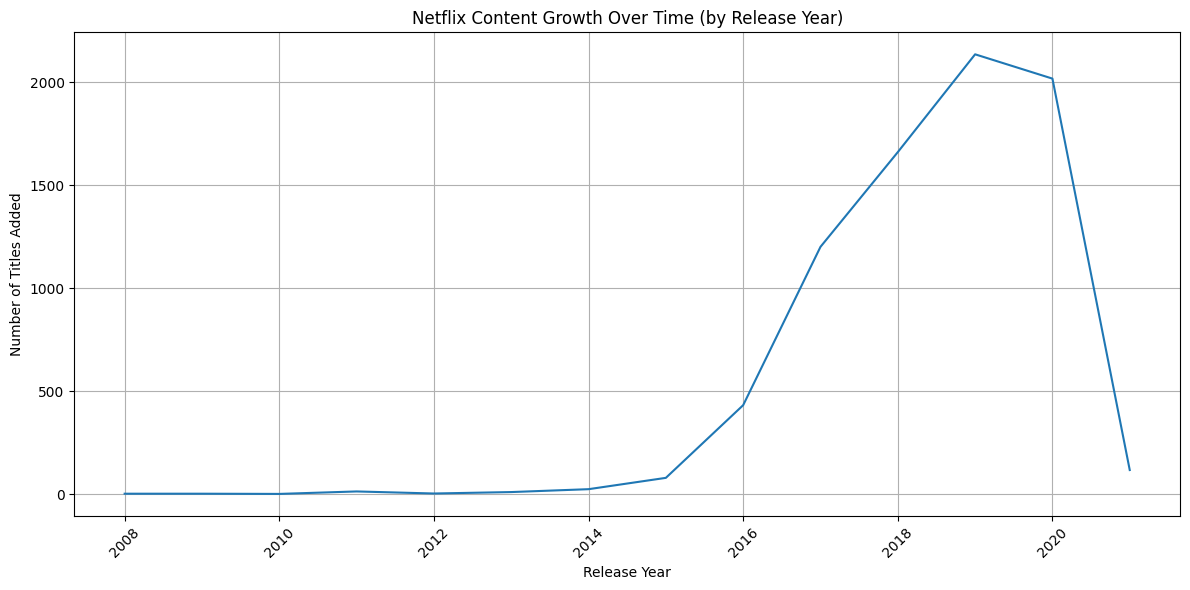

In [9]:
# Visualize the content growth over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='Release_Year', y='Number_of_Titles', data=content_growth)
plt.title('Netflix Content Growth Over Time (by Release Year)')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles Added')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

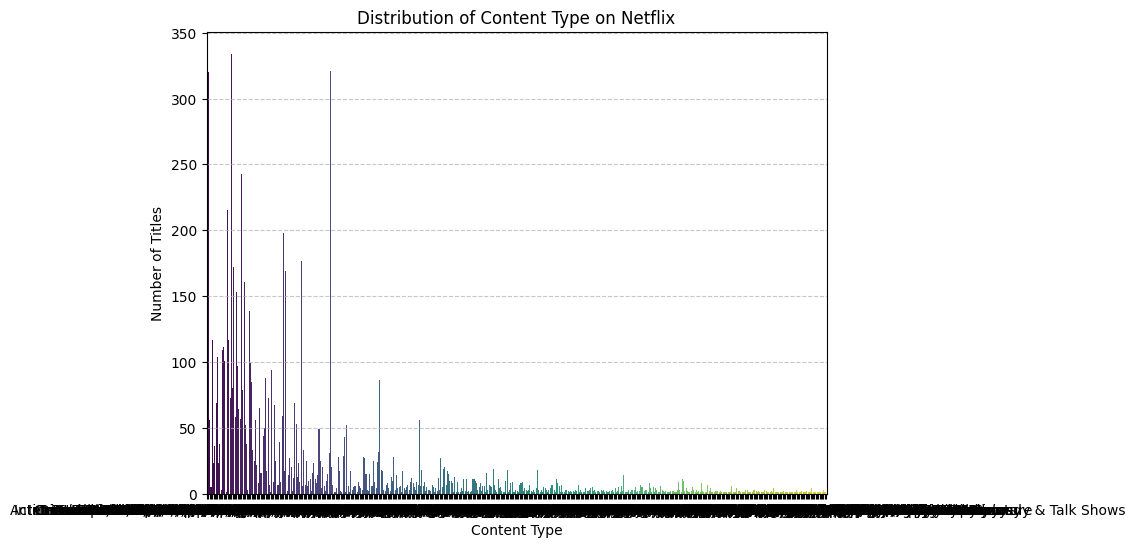

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Type', data=df, palette='viridis', hue='Type', legend=False)
plt.title('Distribution of Content Type on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This plot visualizes the total number of movies and TV shows in the dataset, providing a clear overview of the content distribution by type.

Top 10 Countries with Content Contributions:


,count
Country,
united states,3255
india,989
united kingdom,704
canada,399
france,345
japan,284
spain,211
south korea,207
germany,198


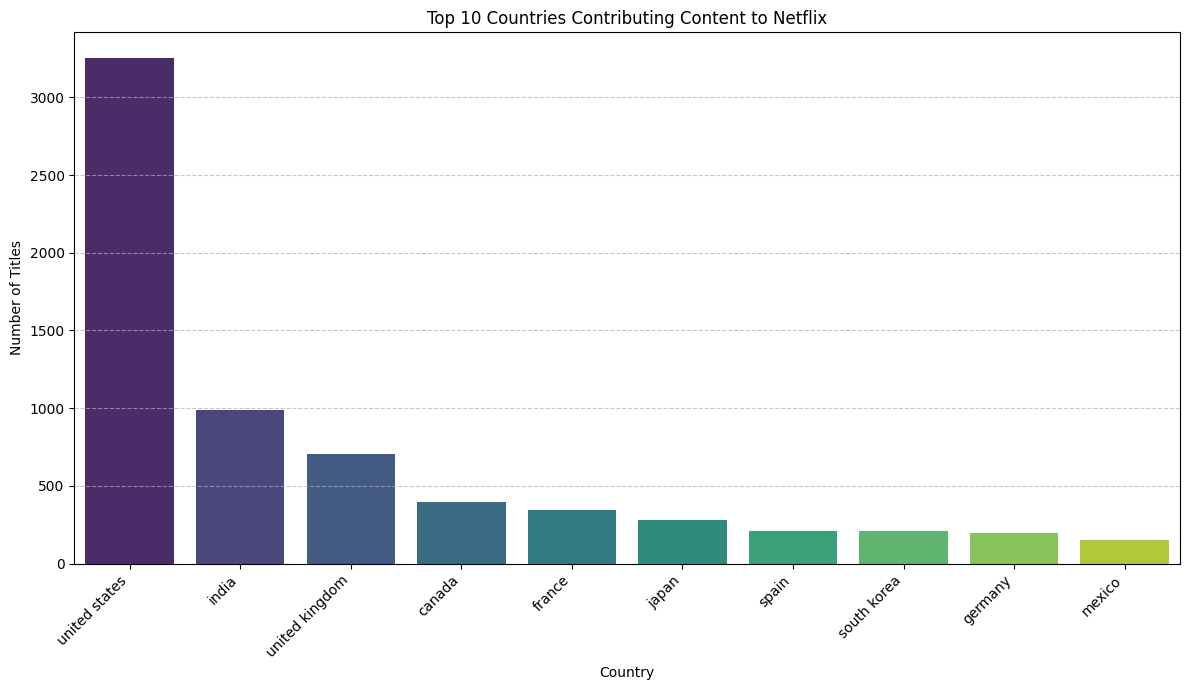

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Split the 'Country' column by comma, expand into rows, and clean each country name
country_contributions = df['Country'].str.split(', ').explode().str.strip().value_counts()

# Filter out 'unknown country'
country_contributions = country_contributions[country_contributions.index != 'unknown country']

# Get the top 10 contributing countries
top_countries = country_contributions.head(10)

print("Top 10 Countries with Content Contributions:")
display(top_countries)

# Visualize the top 10 contributing countries
plt.figure(figsize=(12, 7))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis', hue=top_countries.index, legend=False)
plt.title('Top 10 Countries Contributing Content to Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This plot shows the top 10 countries that have contributed the most content (movies and TV shows) to Netflix, giving insight into the geographic distribution of content production.

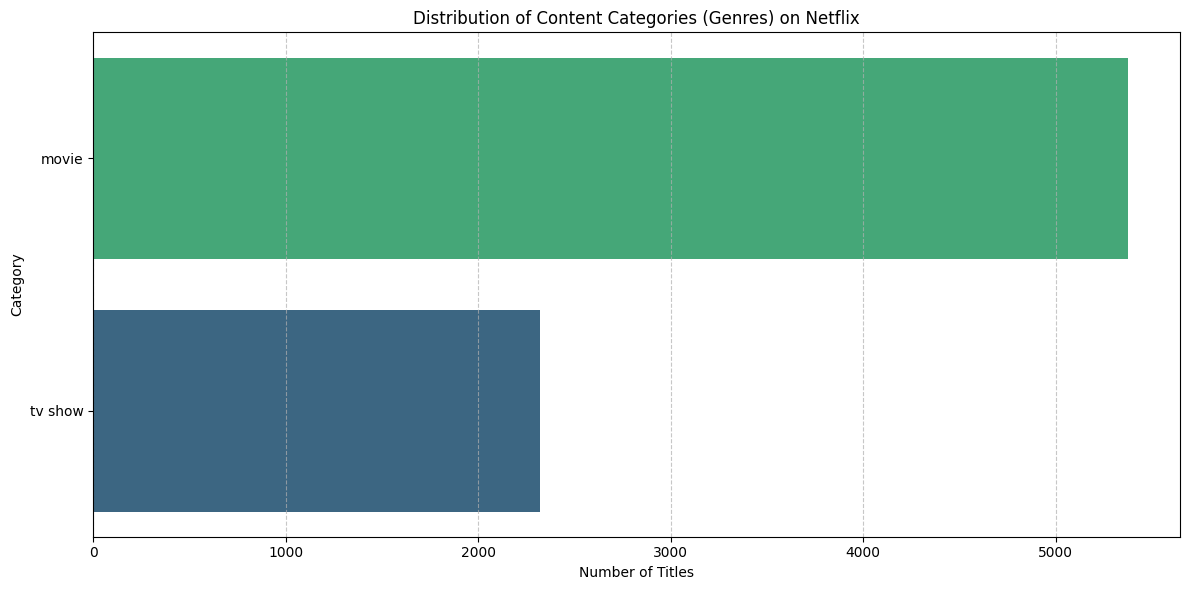

In [13]:
plt.figure(figsize=(12, 6))
sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='viridis', hue='Category', legend=False)
plt.title('Distribution of Content Categories (Genres) on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart displays the distribution of content categories (genres) on Netflix, ordered from most to least frequent. It provides an overview of the types of content most prevalent in the dataset.

### Creating 'Content Length Category' Derived Feature

We will create a new feature called `Content_Length_Category` based on the `Duration` column. This feature will categorize content as follows:

*   **Movies:** 'Short' (<60 min), 'Medium' (60-120 min), 'Long' (>120 min)
*   **TV Shows:** 'Single Season', 'Multiple Seasons' (>1 season)

Count of each Content Length Category:


,count
Content_Length_Category,
Unknown Type,7699


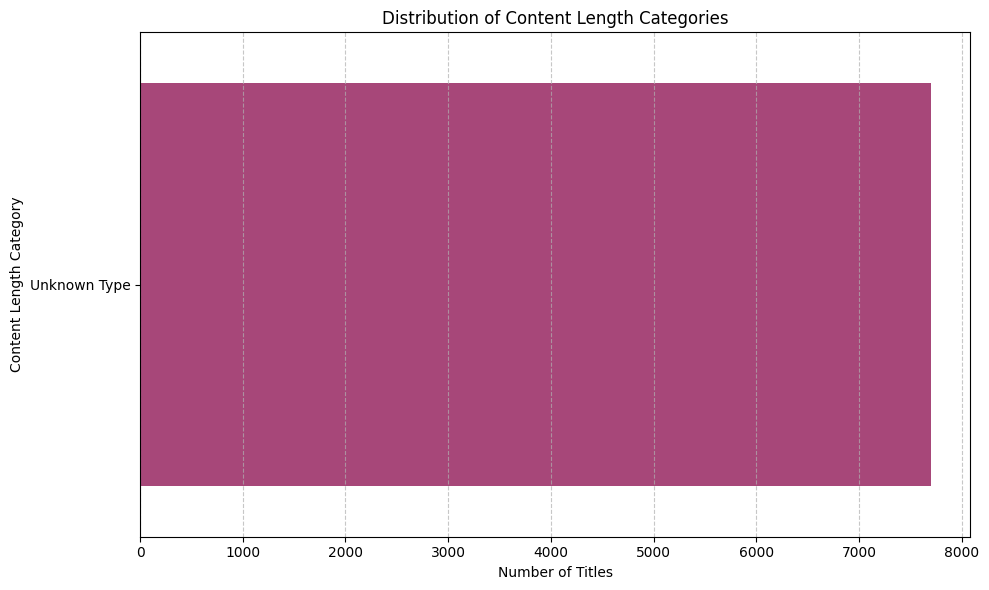

In [15]:
def get_content_length_category(row):
    if row['Type'] == 'movie':
        try:
            duration = int(row['Duration'].split(' ')[0])
            if duration < 60:
                return 'Short Movie'
            elif 60 <= duration <= 120:
                return 'Medium Movie'
            else:
                return 'Long Movie'
        except ValueError:
            return 'Unknown Movie Length'
    elif row['Type'] == 'tv show':
        try:
            seasons = int(row['Duration'].split(' ')[0])
            if seasons == 1:
                return 'Single Season TV Show'
            else:
                return 'Multiple Seasons TV Show'
        except ValueError:
            return 'Unknown TV Show Length'
    return 'Unknown Type'

# Normalize 'Type' column to lowercase before applying the function
df['Type'] = df['Type'].str.lower()
df['Content_Length_Category'] = df.apply(get_content_length_category, axis=1)

print("Count of each Content Length Category:")
display(df['Content_Length_Category'].value_counts())

# Visualize the new feature
plt.figure(figsize=(10, 6))
sns.countplot(y='Content_Length_Category', data=df, order=df['Content_Length_Category'].value_counts().index, palette='magma', hue='Content_Length_Category', legend=False)
plt.title('Distribution of Content Length Categories')
plt.xlabel('Number of Titles')
plt.ylabel('Content Length Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 'Original vs. Licensed' Feature

The current dataset does not contain direct information (e.g., a specific column or metadata) that allows for the derivation of an 'Original vs. Licensed' feature. This type of classification typically requires external data or more detailed dataset attributes not present here. Therefore, this feature cannot be created with the available data.

In [16]:
# Prepare 'Category' for clustering (handling multiple genres)
# First, create a new DataFrame for genres by splitting the 'Category' column and expanding it.
genres_df = df['Category'].str.get_dummies(sep=', ')

# Prepare 'Rating' for clustering
ratings_df = pd.get_dummies(df['Rating'], prefix='Rating')

# Prepare 'Content_Length_Category' for clustering
content_length_df = pd.get_dummies(df['Content_Length_Category'], prefix='Length')

# Concatenate all one-hot encoded features
# Align indices to ensure correct concatenation after dummy variable creation
features_for_clustering = pd.concat([
    genres_df.set_index(df.index),
    ratings_df.set_index(df.index),
    content_length_df.set_index(df.index)
], axis=1)

print("Features prepared for clustering. Here are the first 5 rows:")
display(features_for_clustering.head())


Features prepared for clustering. Here are the first 5 rows:


,movie,tv show,Rating_g,Rating_nc-17,Rating_nr,Rating_pg,Rating_pg-13,Rating_r,Rating_tv-14,Rating_tv-g,Rating_tv-ma,Rating_tv-pg,Rating_tv-y,Rating_tv-y7,Rating_tv-y7-fv,Rating_ur,Length_Unknown Type
0,0,1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True
1,1,0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True
2,1,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
3,1,0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True
4,1,0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True


Now that the features are prepared, we can proceed with determining the optimal number of clusters and then apply a clustering algorithm like K-Means.

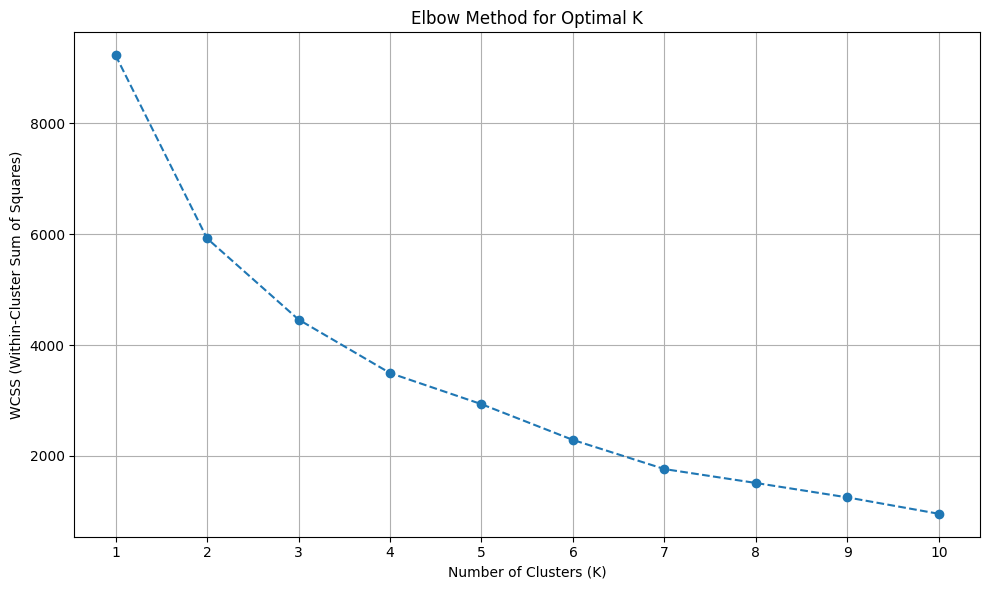

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

wcss = []
# Let's try up to 10 clusters, but you can adjust this range
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(features_for_clustering)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()


This plot displays the WCSS against the number of clusters. The 'elbow' in the curve, where the rate of decrease in WCSS significantly changes, suggests the optimal number of clusters (K). You can visually inspect this plot to determine the best K.

In [18]:
from sklearn.cluster import KMeans

# Assuming K=4 is the optimal number of clusters from the Elbow Method
optimal_k = 4 # You can change this based on your visual inspection of the elbow plot

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster_Label'] = kmeans.fit_predict(features_for_clustering)

print(f"K-Means clustering applied with {optimal_k} clusters.")
print("Distribution of titles across clusters:")
display(df['Cluster_Label'].value_counts())

print("\nFirst 5 rows of the DataFrame with new 'Cluster_Label' column:")
display(df.head())


K-Means clustering applied with 4 clusters.
Distribution of titles across clusters:


,count
Cluster_Label,
1,2322
0,2255
2,1850
3,1272



First 5 rows of the DataFrame with new 'Cluster_Label' column:


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description,Release_Year,Content_Length_Category,Cluster_Label
0,s1,tv show,3%,Unknown Director,"João Miguel, Bianca Comparato, Michel Gomes, R...",brazil,2020-08-14,tv-ma,4 Seasons,"international tv shows, tv dramas, tv sci-fi &...",In a future where the elite inhabit an island ...,2020,Unknown Type,1
1,s2,movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",mexico,2016-12-23,tv-ma,93 min,"dramas, international movies",After a devastating earthquake hits Mexico Cit...,2016,Unknown Type,2
2,s3,movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",singapore,2018-12-20,r,78 min,"horror movies, international movies","When an army recruit is found dead, his fellow...",2018,Unknown Type,0
3,s4,movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",united states,2017-11-16,pg-13,80 min,"action & adventure, independent movies, sci-fi...","In a postapocalyptic world, rag-doll robots hi...",2017,Unknown Type,0
4,s5,movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",united states,2020-01-01,pg-13,123 min,dramas,A brilliant group of students become card-coun...,2020,Unknown Type,0


Now that the K-Means clustering has been applied, each Netflix title in your DataFrame has been assigned a `Cluster_Label`. The next step would be to analyze these clusters to understand their unique characteristics. This could involve examining the dominant genres, ratings, content length categories, and even countries within each cluster.

Cluster Centroids (mean of features per cluster):


,movie,tv show,Rating_g,Rating_nc-17,Rating_nr,Rating_pg,Rating_pg-13,Rating_r,Rating_tv-14,Rating_tv-g,Rating_tv-ma,Rating_tv-pg,Rating_tv-y,Rating_tv-y7,Rating_tv-y7-fv,Rating_ur,Length_Unknown Type
Cluster_Label,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.017295,0.00133,0.035033,0.109534,0.171175,0.294013,0.000000,0.049224,0.000000,0.223947,0.051885,0.042129,0.002217,0.002217,1.0
1,0.0,1.0,0.000000,0.00000,0.001723,0.000000,0.000000,0.000861,0.273471,0.032300,0.429802,0.119724,0.067614,0.074505,0.000000,0.000000,1.0
2,1.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
3,1.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0


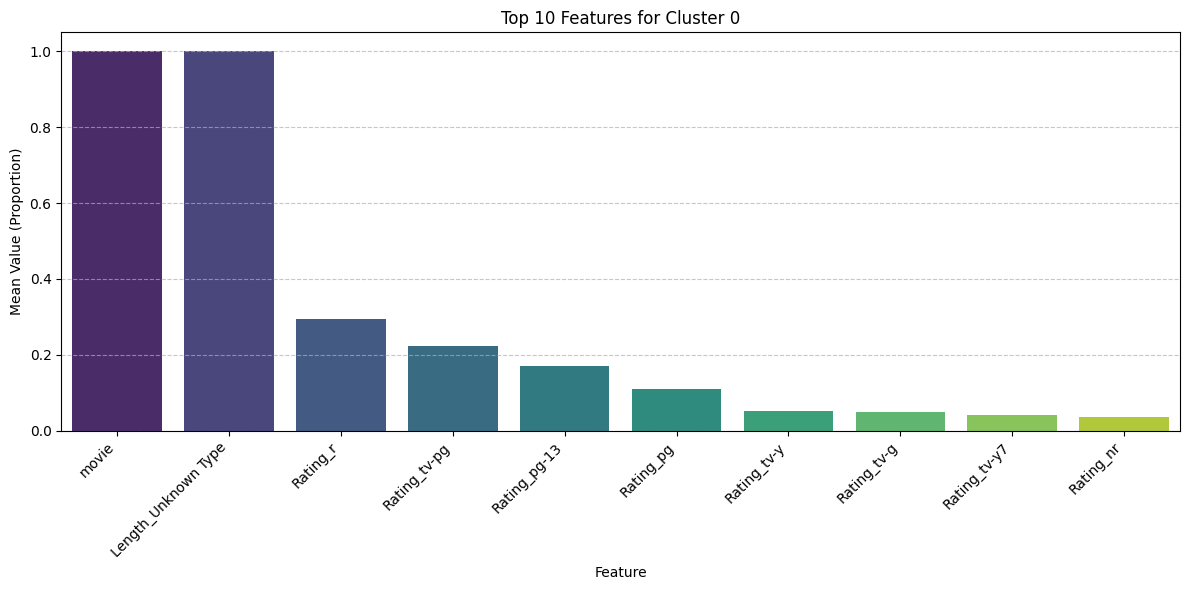

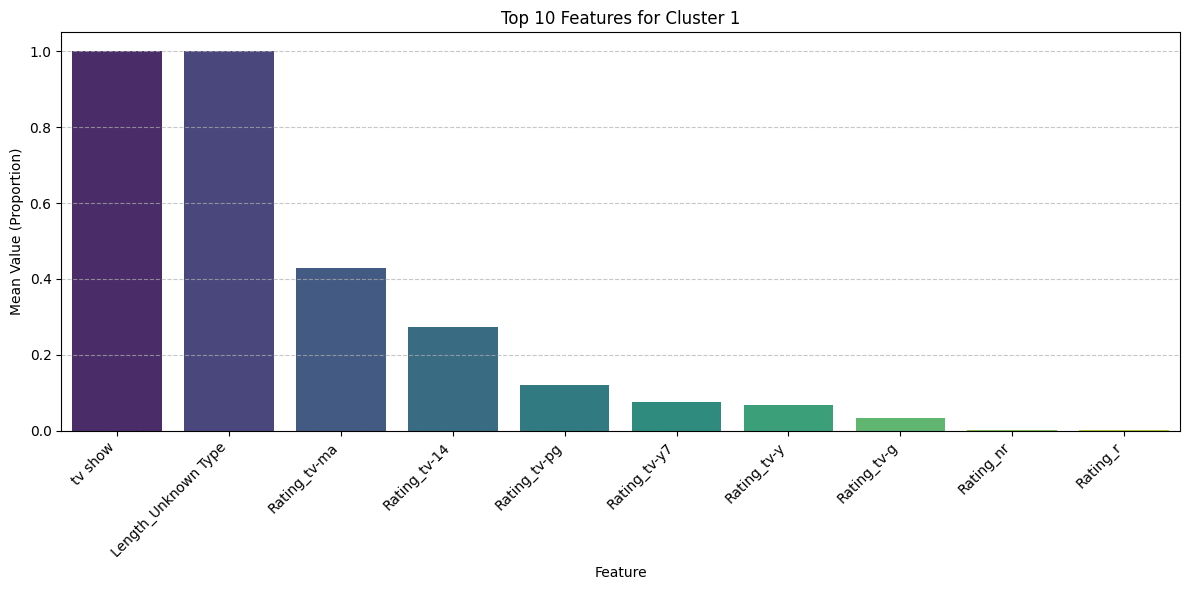

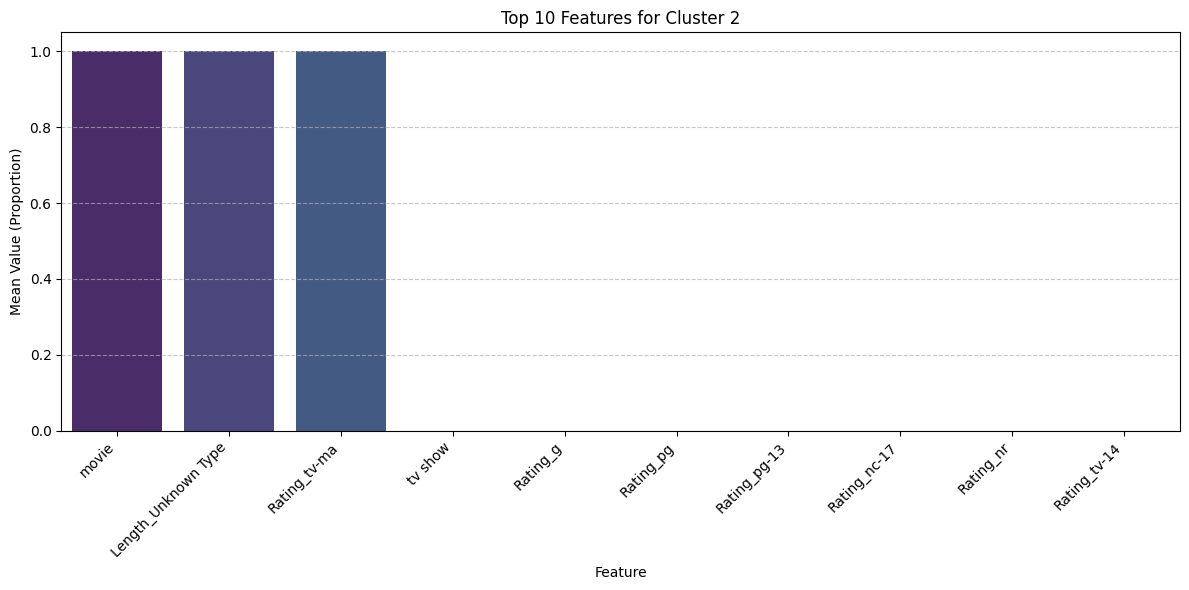

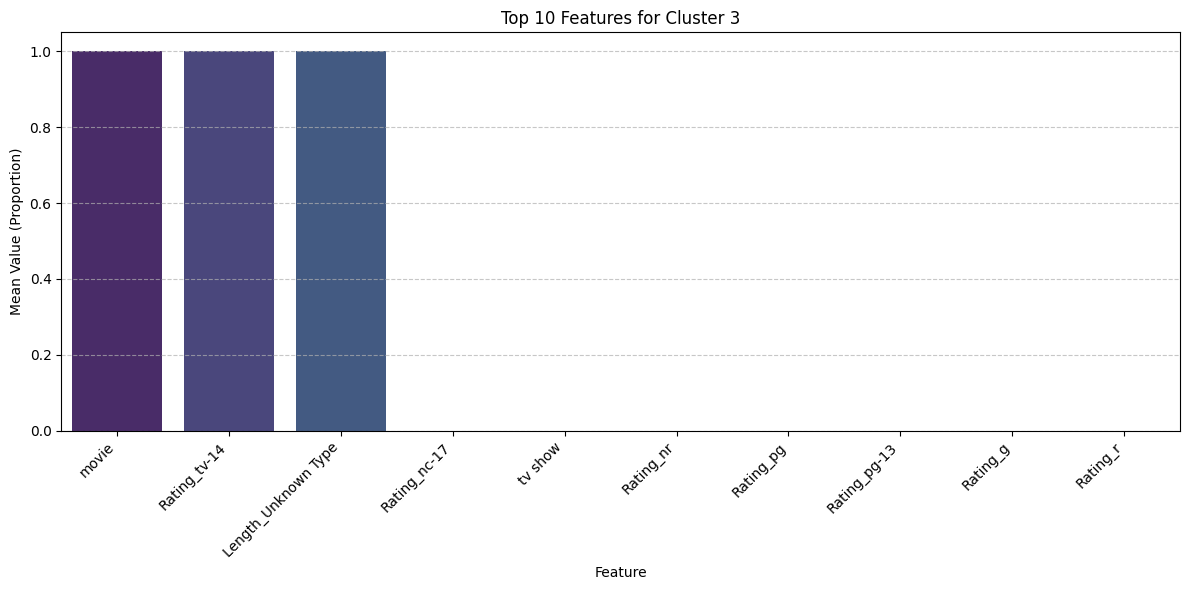

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the cluster centroids (mean of features for each cluster)
# Corrected: Group features_for_clustering by the Cluster_Label from df
cluster_centroids = features_for_clustering.groupby(df['Cluster_Label']).mean()

print("Cluster Centroids (mean of features per cluster):")
display(cluster_centroids)

# Visualize top features for each cluster
num_top_features = 10 # You can adjust this number

for i in range(len(cluster_centroids)):
    plt.figure(figsize=(12, 6))
    # Sort features by their mean value for the current cluster and get the top N
    top_features_per_cluster = cluster_centroids.iloc[i].sort_values(ascending=False).head(num_top_features)
    sns.barplot(x=top_features_per_cluster.index, y=top_features_per_cluster.values, palette='viridis', hue=top_features_per_cluster.index, legend=False)
    plt.title(f'Top {num_top_features} Features for Cluster {i}')
    plt.xlabel('Feature')
    plt.ylabel('Mean Value (Proportion)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

These visualizations show the top features (genres, ratings, and content length categories) that are most prevalent in each cluster. By examining these bar charts, you can understand the distinct characteristics and themes that define each group of Netflix content.

Distribution of 'Category' column:


,count
Category,
movie,5377
tv show,2322


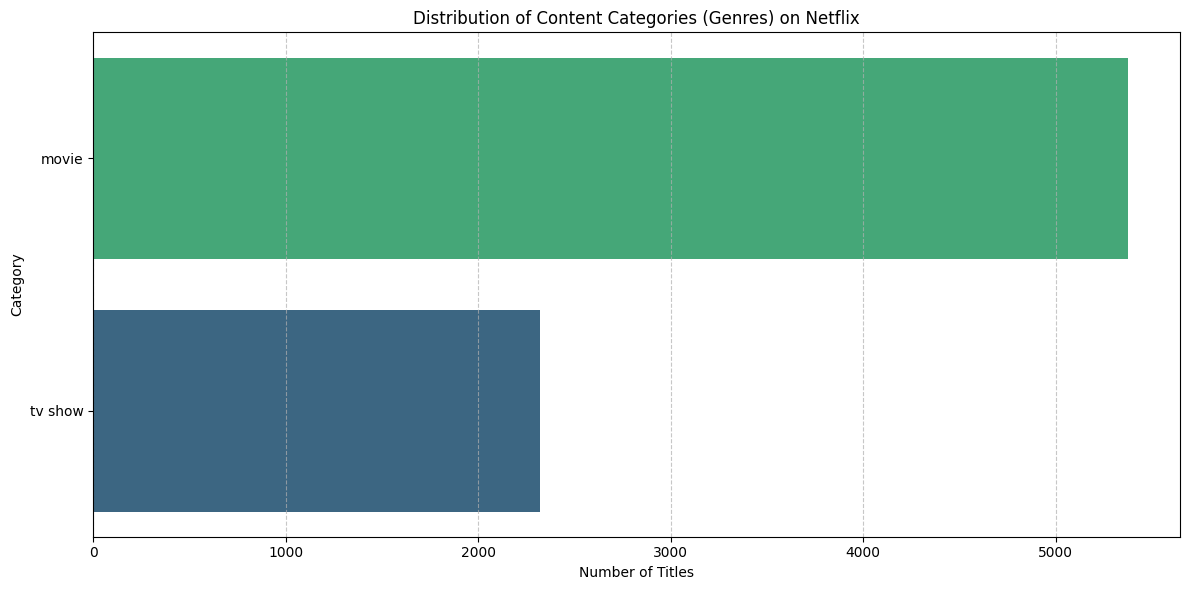

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Distribution of 'Category' column:")
display(df['Category'].value_counts())

plt.figure(figsize=(12, 6))
sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='viridis', hue='Category', legend=False)
plt.title('Distribution of Content Categories (Genres) on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top 10 Categories for Movies:


,count
Category,
movie,5377



Top 10 Categories for TV Shows:


,count
Category,
tv show,2322


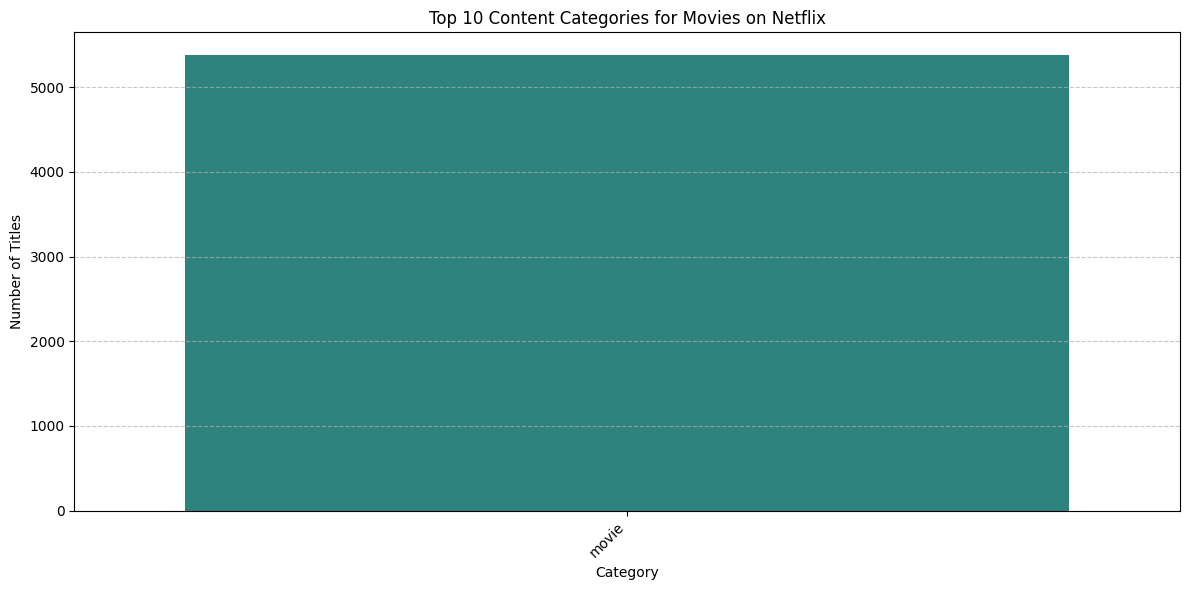

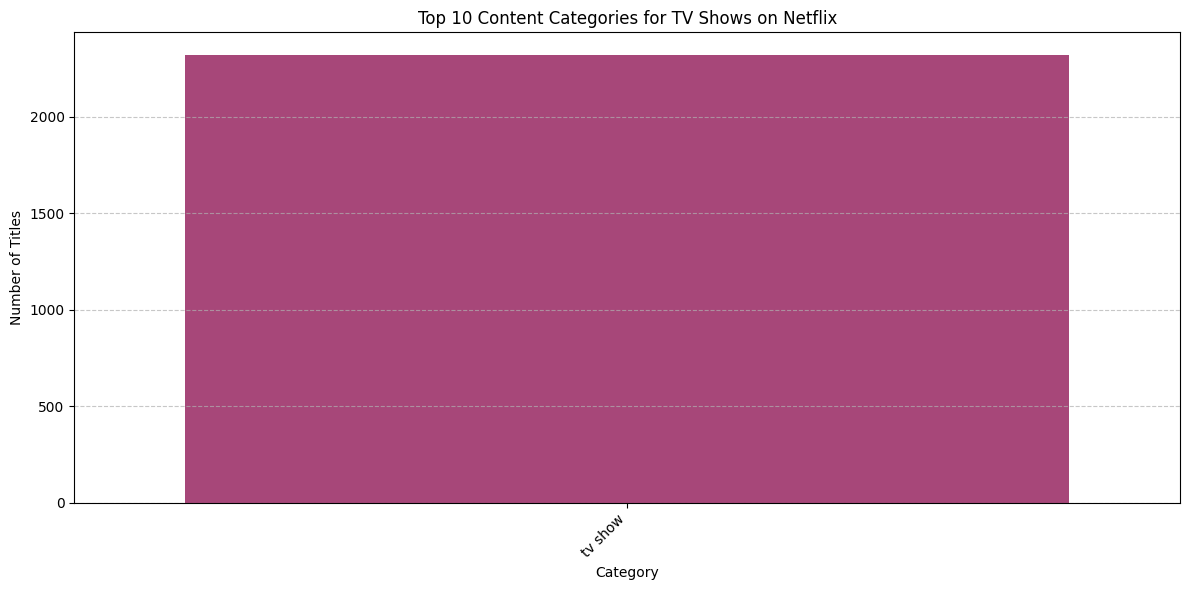

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for movies and get category distribution
movies_df = df[df['Category'] == 'movie']
movies_category_dist = movies_df['Category'].value_counts().head(10) # Top 10 for better visualization

# Filter for TV shows and get category distribution
tvshows_df = df[df['Category'] == 'tv show']
tvshows_category_dist = tvshows_df['Category'].value_counts().head(10) # Top 10 for better visualization

print("Top 10 Categories for Movies:")
display(movies_category_dist)

print("\nTop 10 Categories for TV Shows:")
display(tvshows_category_dist)

# Visualize the distribution for Movies
plt.figure(figsize=(12, 6))
sns.barplot(x=movies_category_dist.index, y=movies_category_dist.values, palette='viridis', hue=movies_category_dist.index, legend=False)
plt.title('Top 10 Content Categories for Movies on Netflix')
plt.xlabel('Category')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualize the distribution for TV Shows
plt.figure(figsize=(12, 6))
sns.barplot(x=tvshows_category_dist.index, y=tvshows_category_dist.values, palette='magma', hue=tvshows_category_dist.index, legend=False)
plt.title('Top 10 Content Categories for TV Shows on Netflix')
plt.xlabel('Category')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-create df_countries_exploded by splitting and exploding the 'Country' column
df_countries_exploded = df.assign(Country=df['Country'].str.split(', ')).explode('Country')
df_countries_exploded['Country'] = df_countries_exploded['Country'].str.strip().str.lower()

# Filter out 'unknown country' entries
df_countries_exploded = df_countries_exploded[df_countries_exploded['Country'] != 'unknown country']

print("Re-created df_countries_exploded. Here are the first 5 rows:")
display(df_countries_exploded.head())

Re-created df_countries_exploded. Here are the first 5 rows:


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description,Release_Year,Content_Length_Category,Cluster_Label
0,s1,tv show,3%,Unknown Director,"João Miguel, Bianca Comparato, Michel Gomes, R...",brazil,2020-08-14,tv-ma,4 Seasons,"international tv shows, tv dramas, tv sci-fi &...",In a future where the elite inhabit an island ...,2020,Unknown Type,1
1,s2,movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",mexico,2016-12-23,tv-ma,93 min,"dramas, international movies",After a devastating earthquake hits Mexico Cit...,2016,Unknown Type,2
2,s3,movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",singapore,2018-12-20,r,78 min,"horror movies, international movies","When an army recruit is found dead, his fellow...",2018,Unknown Type,0
3,s4,movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",united states,2017-11-16,pg-13,80 min,"action & adventure, independent movies, sci-fi...","In a postapocalyptic world, rag-doll robots hi...",2017,Unknown Type,0
4,s5,movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",united states,2020-01-01,pg-13,123 min,dramas,A brilliant group of students become card-coun...,2020,Unknown Type,0


Content availability by country (top 10):


,Country,Number_of_Titles
0,united states,3255
1,india,989
2,united kingdom,704
3,canada,399
4,france,345
5,japan,284
6,spain,211
7,south korea,207
8,germany,198
9,mexico,154


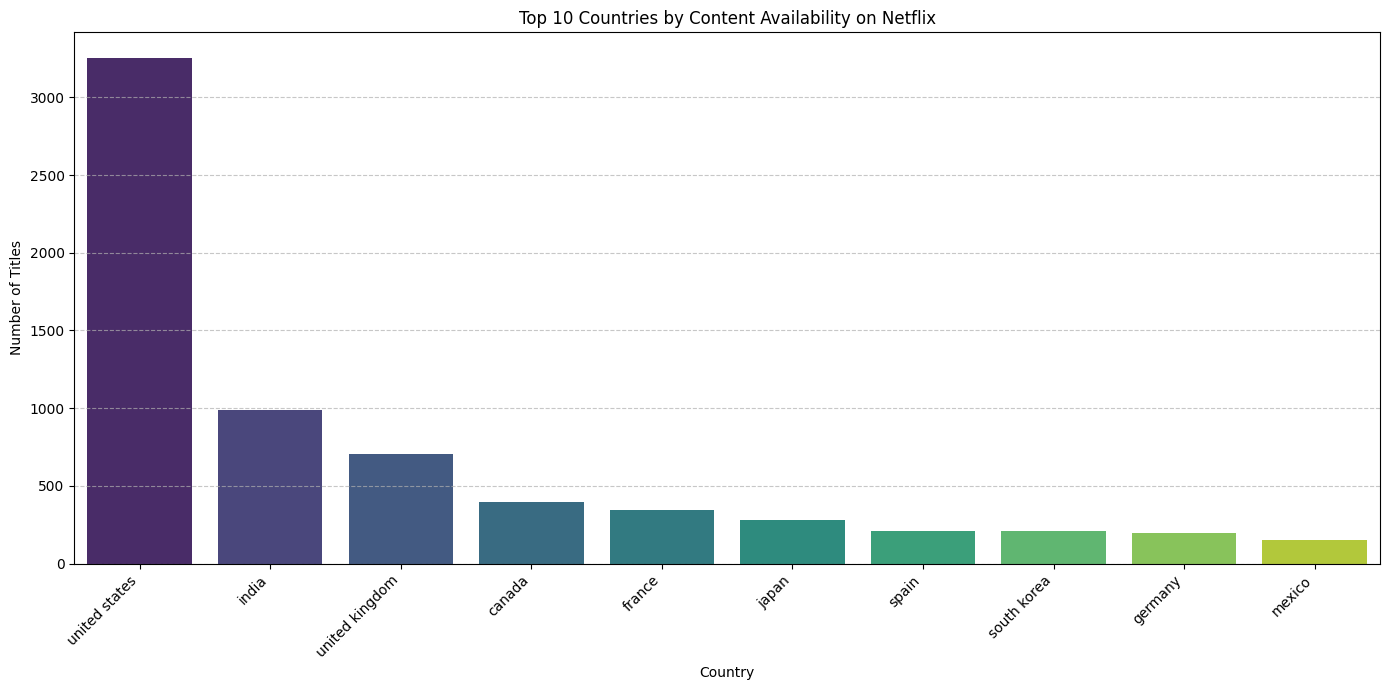

In [28]:
# Count content availability per country
country_availability = df_countries_exploded['Country'].value_counts().reset_index()
country_availability.columns = ['Country', 'Number_of_Titles']

print("Content availability by country (top 10):")
display(country_availability.head(10))

# Visualize top countries by content availability
plt.figure(figsize=(14, 7))
sns.barplot(x='Country', y='Number_of_Titles', data=country_availability.head(10), palette='viridis', hue='Country', legend=False)
plt.title('Top 10 Countries by Content Availability on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This visualization shows the countries with the highest number of titles available on Netflix, providing insight into the geographic distribution of content.

### Interpreting Classification Results: Feature Importance

To understand which features are most influential in classifying content as a 'movie' or 'tv show', we will train a `RandomForestClassifier` and then analyze its feature importances. This will highlight the key characteristics that differentiate movies from TV shows in our dataset.

Accuracy: 0.72

Classification Report:
              precision    recall  f1-score   support

       movie       0.73      0.96      0.83      1648
     tv show       0.55      0.13      0.21       662

    accuracy                           0.72      2310
   macro avg       0.64      0.54      0.52      2310
weighted avg       0.68      0.72      0.65      2310


Top 15 Feature Importances:


,0
Rating_r,0.245445
Release_Year,0.212198
Rating_pg-13,0.152094
Rating_tv-y7,0.120430
Rating_pg,0.089830
Rating_tv-y,0.042727
Rating_tv-ma,0.037627
Rating_tv-14,0.027822
Rating_nr,0.023989
Rating_tv-pg,0.019958


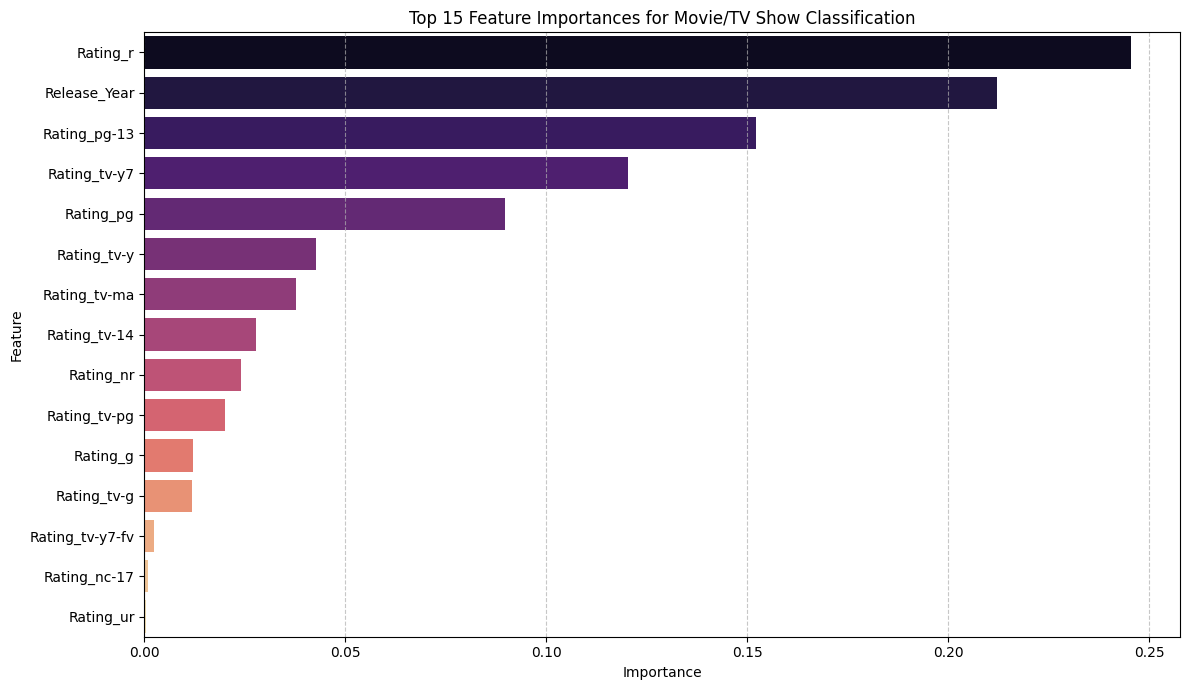

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare features (X) and target (y)
# According to context, exclude 'movie' and 'tv show' from features_for_clustering directly
# as 'Category' is the target variable.
# Also, add 'Release_Year' as a feature.

# Ensure 'features_for_clustering' is numeric (it contains booleans from get_dummies)
features_for_clustering_numeric = features_for_clustering.astype(int)

# Drop 'movie' and 'tv show' columns if they exist, as 'Category' is our target.
# We need to make sure these columns are not used as features to predict themselves.
features_to_drop_from_X = ['movie', 'tv show']
existing_features_to_drop = [col for col in features_to_drop_from_X if col in features_for_clustering_numeric.columns]

X_temp = features_for_clustering_numeric.drop(columns=existing_features_to_drop, errors='ignore')

# Add 'Release_Year' as a feature
X = pd.concat([X_temp, df['Release_Year']], axis=1)

y = df['Category'] # Corrected: Target variable should be 'Category' column for movie/tv show classification

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = classifier.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Get feature importances
feature_importances = pd.Series(classifier.feature_importances_, index=X.columns)

# Sort feature importances and get the top N
num_top_features_to_display = 15 # You can adjust this number
top_features = feature_importances.nlargest(num_top_features_to_display)

print(f"\nTop {num_top_features_to_display} Feature Importances:")
display(top_features)

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=top_features.values, y=top_features.index, palette='magma', hue=top_features.index, legend=False)
plt.title(f'Top {num_top_features_to_display} Feature Importances for Movie/TV Show Classification')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This analysis provides a classification model's accuracy and highlights the features most important for distinguishing between movies and TV shows. The bar chart visually represents these importances, allowing us to interpret which characteristics most strongly influence the content type prediction.

### Milestone 4: Creating an Interactive Visualization

As a step towards a fully functional interactive dashboard, let's create an interactive plot that allows us to filter the content growth by year. This will use `ipywidgets` and `matplotlib` to demonstrate interactive filtering within the notebook.

In [32]:
import ipywidgets as widgets
from IPython.display import display

# Get the range of years available in the content_growth DataFrame
min_year = int(content_growth['Release_Year'].min())
max_year = int(content_growth['Release_Year'].max())

# Create a slider widget for selecting a year range
year_slider = widgets.IntRangeSlider(
    value=[min_year, max_year],
    min=min_year,
    max=max_year,
    step=1,
    description='Release Year:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
)

def plot_filtered_content_growth(year_range):
    filtered_df = content_growth[
        (content_growth['Release_Year'] >= year_range[0]) &
        (content_growth['Release_Year'] <= year_range[1])
    ]

    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Release_Year', y='Number_of_Titles', data=filtered_df)
    plt.title(f'Netflix Content Growth ({year_range[0]} - {year_range[1]})')
    plt.xlabel('Release Year')
    plt.ylabel('Number of Titles Added')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Link the slider to the plotting function
interactive_plot = widgets.interactive(plot_filtered_content_growth, year_range=year_slider)
display(interactive_plot)

interactive(children=(IntRangeSlider(value=(2008, 2021), continuous_update=False, description='Release Year:',…